In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/feature_engineered.csv", parse_dates=["Date"])
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

print(df.shape)
df.head()


(417049, 27)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,sales_rolling_7,price_proxy,log_sales,log_price,lag_1,lag_7,volatility_7,trend_7,regime
0,2,4,2013-01-10,5618,637,1,1,0,0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",5208.428571,0.85,8.633731,-0.162519,8.819222,8.394347,0.381126,8.503595,volatile
1,2,5,2013-01-11,4810,539,1,1,0,0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",5301.428571,0.85,8.478452,-0.162519,8.633731,8.333030,0.374179,8.524370,volatile
2,2,6,2013-01-12,2630,337,1,0,0,0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",5036.571429,1.00,7.874739,0.000000,8.478452,8.408271,0.448690,8.448151,decline
3,2,1,2013-01-14,3995,530,1,0,0,0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",5272.714286,1.00,8.292799,0.000000,7.874739,7.758761,0.345464,8.524442,volatile
4,2,2,2013-01-15,4075,513,1,0,0,0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",4887.000000,1.00,8.312626,0.000000,8.292799,8.820995,0.325595,8.451818,decline


In [3]:
features = ["log_price", "lag_1", "lag_7", "Promo", "volatility_7", "trend_7"]

X = df[features]
y = df["log_sales"]

X = sm.add_constant(X)

baseline_model = sm.OLS(y, X).fit()
baseline_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_sales   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.730
Method:                 Least Squares   F-statistic:                 2.258e+05
Date:                Mon, 09 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:26:38   Log-Likelihood:                 58268.
No. Observations:              417049   AIC:                        -1.165e+05
Df Residuals:                  417043   BIC:                        -1.165e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.6375      0.009     69.876      0.000       0.620       0.655
log_price       -0.0528      0.000   -413.498      0.000      -0.053      -0.053
lag_1           -0.0224      0.001    -15.414      0.000      -0.025      -0.020
lag_7            0.0604      0.001     49.275      0.000       0.058       0.063
Promo            0.3249      0.001    413.498      0.000       0.323       0.326
volatility_7    -0.1127      0.003    -34.740      0.000      -0.119      -0.106
trend_7          0.8748      0.002    462.780      0.000       0.871       0.879
==============================================================================
Omnibus:                    16822.206   Durbin-Watson:                   1.349
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            52473.892
Skew:                           0.087   Prob(JB):                         0.00
Kurtosis:                       4.729   Cond. No.                     1.04e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 8.79e-23. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [4]:
baseline_elasticity = baseline_model.params["log_price"]
baseline_elasticity


np.float64(-0.052809295601921345)

In [5]:
regime_results = []

for regime in df["regime"].unique():
    sub = df[df["regime"] == regime]

    X_r = sub[features]
    y_r = sub["log_sales"]

    X_r = sm.add_constant(X_r)

    model_r = sm.OLS(y_r, X_r).fit()

    regime_results.append({
        "regime": regime,
        "elasticity": model_r.params["log_price"],
        "r2": model_r.rsquared,
        "n_obs": len(sub)
    })

regime_df = pd.DataFrame(regime_results)
regime_df


,regime,elasticity,r2,n_obs
0,volatile,-0.101426,0.602873,48722
1,decline,-0.067146,0.536484,104262
2,stable,-0.036730,0.492894,159803
3,growth,-0.041573,0.533079,104262


In [6]:
regime_df.to_csv("../outputs/tables/regime_elasticity.csv", index=False)


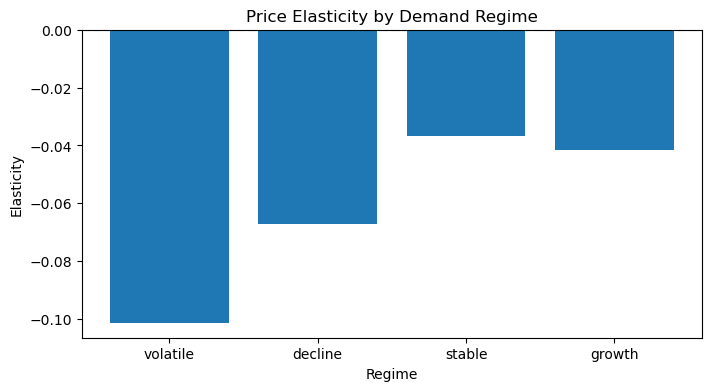

In [7]:
plt.figure(figsize=(8,4))
plt.bar(regime_df["regime"], regime_df["elasticity"])
plt.axhline(0, linestyle="--")
plt.title("Price Elasticity by Demand Regime")
plt.ylabel("Elasticity")
plt.xlabel("Regime")
plt.show()


In [8]:
#Store level Elasticity
store_elasticity = []

for store, sub in df.groupby("Store"):
    if len(sub) < 200:
        continue

    X_s = sub[features]
    y_s = sub["log_sales"]

    X_s = sm.add_constant(X_s)

    model_s = sm.OLS(y_s, X_s).fit()

    store_elasticity.append({
        "Store": store,
        "elasticity": model_s.params["log_price"],
        "r2": model_s.rsquared
    })

store_df = pd.DataFrame(store_elasticity)
store_df.head()


,Store,elasticity,r2
0,2,-0.087851,0.637029
1,3,-0.086055,0.686785
2,11,-0.036762,0.582909
3,12,-0.061527,0.646038
4,13,-0.068134,0.657678


In [9]:
store_df.to_csv("../outputs/tables/store_elasticity.csv", index=False)


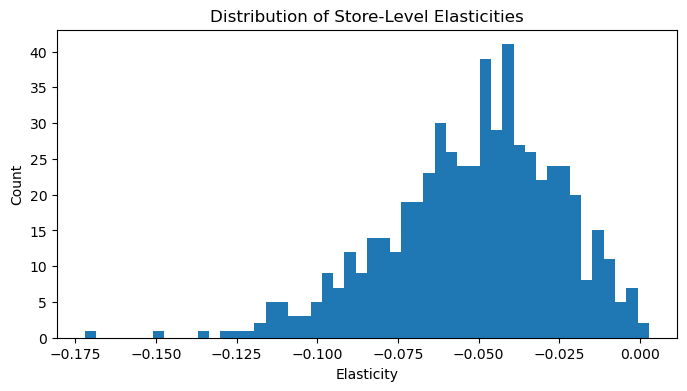

In [10]:
plt.figure(figsize=(8,4))
plt.hist(store_df["elasticity"], bins=50)
plt.title("Distribution of Store-Level Elasticities")
plt.xlabel("Elasticity")
plt.ylabel("Count")
plt.show()


In [11]:
df.to_csv("../data/processed/elasticity_ready.csv", index=False)
